## Importações

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

# modes = ["fast", "medium", "slow"]
centralities = ["central", "peripheral"]
years = range(2019, 2025)

portfolios = {}

for year in years:
    for centrality in centralities:
        cols = pd.read_csv(f"../../data/06_portfolios/{centrality}_{year}.csv", index_col="Date").columns.tolist()
        portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")[cols]

# for year in years:
#     for centrality in centralities:
#         for n in range(10,110,10):
#             cols = pd.read_csv(f"../../data/06_portfolios/{n}_{centrality}_{year}.csv", index_col="Date").columns.tolist()
#             portfolios[f"{n}_{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")[cols]

In [178]:
weekly_returns = {}

for name, portfolio in portfolios.items():
    log_returns = np.log1p(portfolio)  # log(1 + r)
    weekly_returns[name] = log_returns.resample("W-FRI").sum().mean(axis=1)

## Lead-lag

In [179]:
def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu = X_t.mean().values

    Xc_t = X_t.values - mu
    Xc_tk = X_tk.values - mu

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    var = X.var(ddof=0).values
    D_inv_sqrt = np.diag(1 / np.sqrt(var))

    return D_inv_sqrt @ Sigma_k @ D_inv_sqrt


def plot_antisymmetric_autocorr(
    returns_list,
    column_names,
    labels,
    lags=(1, 2, 3, 4),
    figsize=(12, 8),
    cmap="Blues",
    title_prefix="Y",
    annot=False,
    diff=True,
    fig_title=None
):
    X = pd.concat(returns_list, axis=1)
    X.columns = column_names

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    if len(lags) == 1:
        axes = [axes]

    for ax, lag in zip(axes, lags):
        T = autocorrelation_matrix(X, lag)

        if diff:
            A = pd.DataFrame(
                T - T.T,
                index=labels,
                columns=labels
            )
            title = f"{title_prefix}({lag}) - {title_prefix}'({lag})"
        else:
            A = pd.DataFrame(
                T,
                index=labels,
                columns=labels
            )
            title = f"{title_prefix}({lag})"

        sns.heatmap(A, ax=ax, cmap=cmap, center=0, annot=annot)
        ax.set_title(title)

    if fig_title:
        fig.suptitle(fig_title, fontsize=14)
    plt.tight_layout()
    plt.show()

### Central Peripheral

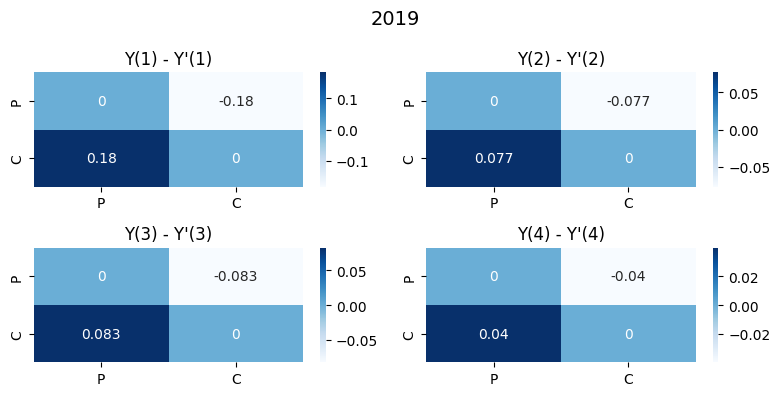

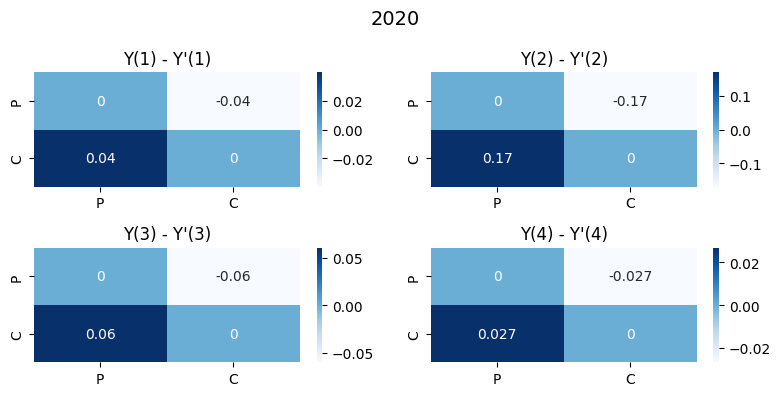

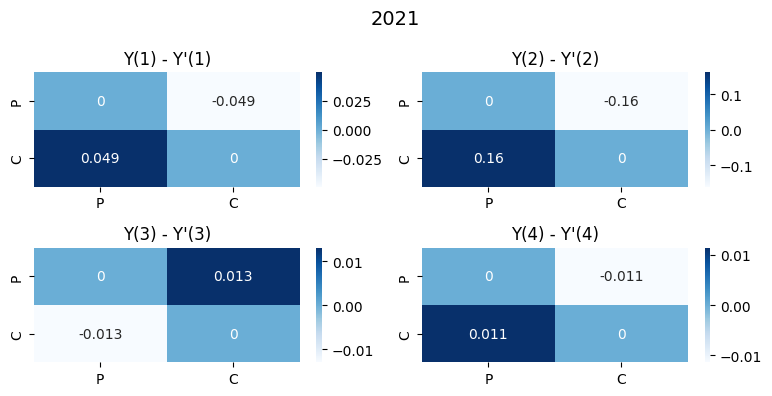

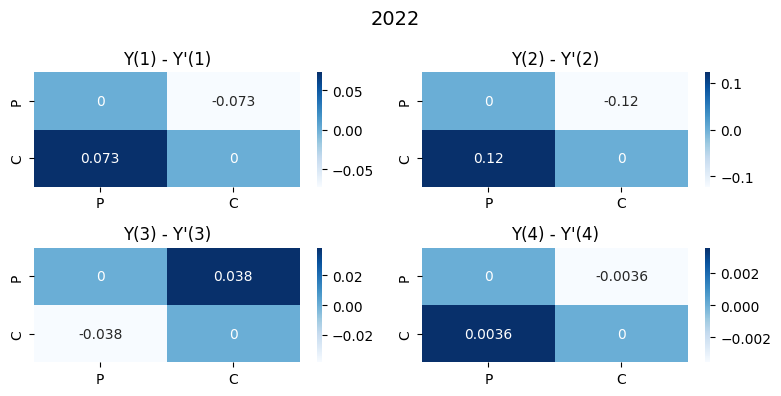

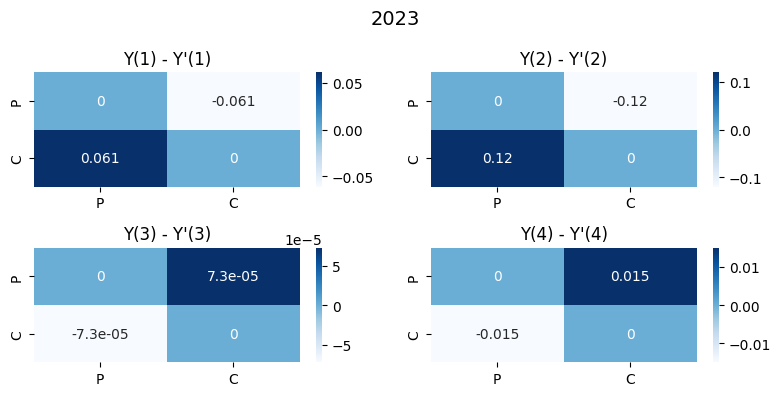

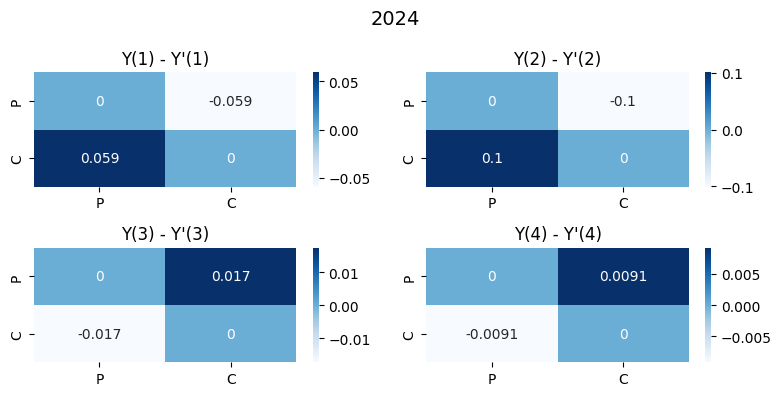

In [180]:
years = range(2019, 2025)

for year in years:
    try:
        R1 = weekly_returns[f"peripheral_{year}"]
        R2 = weekly_returns[f"central_{year}"]

        plot_antisymmetric_autocorr(
            returns_list=[R1, R2],
            column_names=[
                "Peripheral", "Central"
            ],
            labels=["P", "C"],
            annot=True,
            fig_title=f"{year}",
            lags=(1, 2, 3, 4),
            figsize=(8,4)
        )

    except KeyError as e:
        print(f"Missing data for {year}: {e}")

    # =============================
    # 5. Lead–lag matrix
    # =============================
    matrix = []

    X = pd.concat([R1, R2], axis=1)
    X.columns = ["Peripheral", "Central"]
    lag_list = [1, 2, 3, 4]

    for lag in lag_list:
        acm = autocorrelation_matrix(X, lag)
        lag_matrix = acm - acm.T

        matrix.append(
            lag_matrix[1, 0]
        )

    # =============================
    # 6. DataFrame final
    # =============================
    leadlags = ["cp"]
    cols = [f"{leadlag}{i}" for i in lag_list for leadlag in leadlags]

    leadlag_df = pd.DataFrame(
        [np.hstack(matrix)],
        columns=cols,
        index=[year]
    )

    leadlag_df.to_csv(
        f"../../data/08_lead_lag/leadlag_df_{year}.csv"
    )

### Lead-lag considerando Market Cap

In [181]:
df_mcap = pd.read_csv(
    "../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv"
)

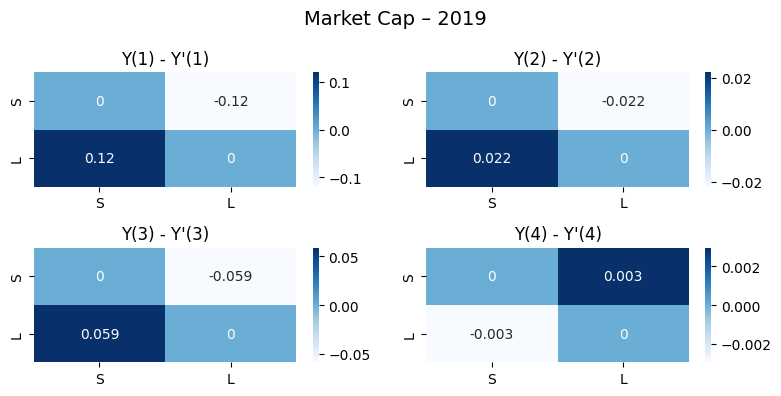

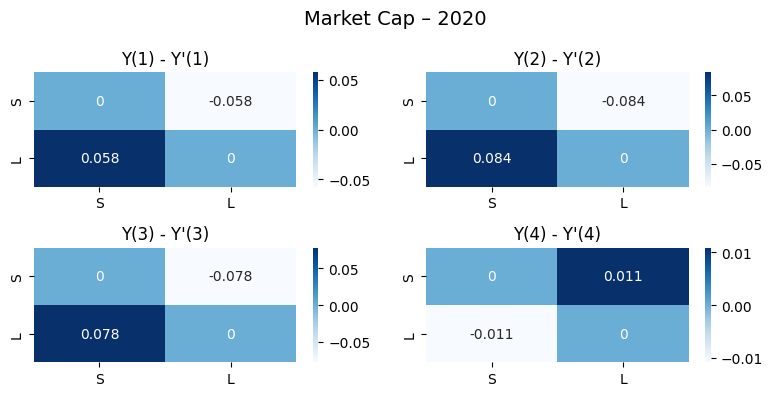

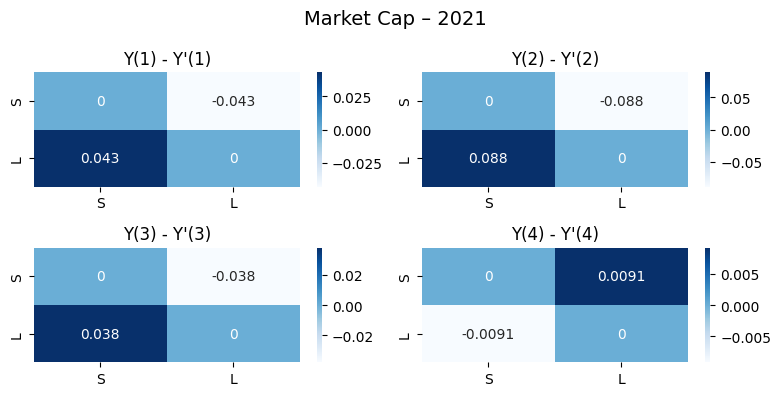

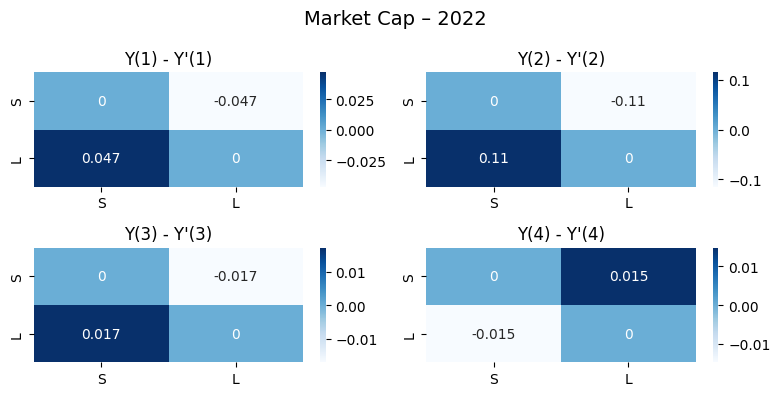

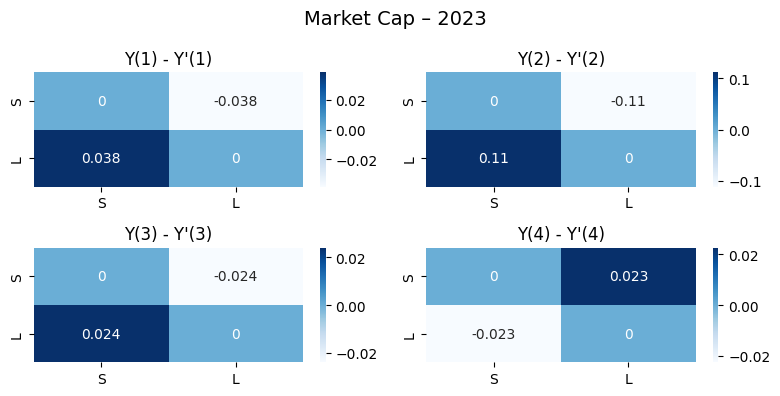

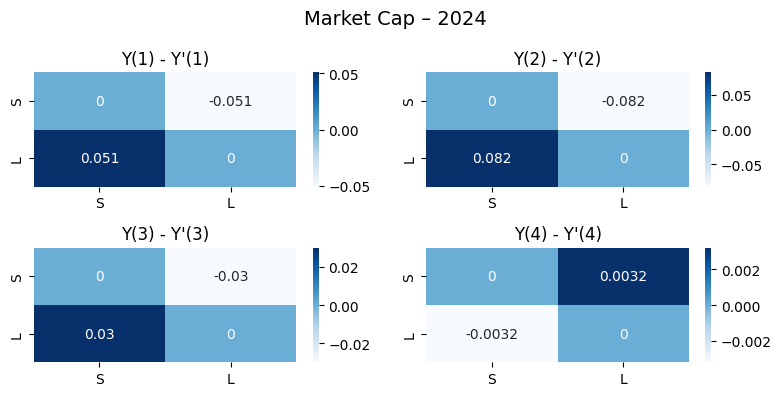

In [182]:
years = range(2019, 2025)
lag_list = [1, 2, 3, 4]

for year in years:
    # =============================
    # 1. Market cap bins do ano
    # =============================
    df_mcap[f"mcap_{year}"] = (
        df_mcap[f"mcap_{year}"]
            .replace("#ERROR!", np.nan)
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
    )

    df_mcap[f"mcap_{year}"] = pd.to_numeric(
        df_mcap[f"mcap_{year}"],
        errors="coerce"
    )

    df_mcap["mcap_bin"] = pd.qcut(
        df_mcap[f"mcap_{year}"],
        q=2,
        labels=["Small", "Large"],
        duplicates="drop"
    )

    # =============================
    # 2. Retornos do portfolio
    # =============================
    returns_prev = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")
    df_mcap = df_mcap[df_mcap["Ticker"].isin(returns_prev.columns)]

    # =============================
    # 3. Portfólios por Market Cap
    # =============================
    R1 = np.log1p(returns_prev[
        df_mcap[df_mcap["mcap_bin"] == "Small"]["Ticker"]
    ]).resample("W-FRI").sum().mean(axis=1)

    R2 = np.log1p(returns_prev[
        df_mcap[df_mcap["mcap_bin"] == "Large"]["Ticker"]
    ]).resample("W-FRI").sum().mean(axis=1)

    # =============================
    # 4. Plot (opcional)
    # =============================
    plot_antisymmetric_autocorr(
        returns_list=[R1, R2],
        column_names=["Small", "Large"],
        labels=["S", "L"],
        annot=True,
        fig_title=f"Market Cap – {year}",
        lags=(1,2,3,4),
        figsize=(8,4)
    )

    # =============================
    # 5. Lead–lag matrix
    # =============================
    matrix = []

    X = pd.concat([R1, R2], axis=1)
    X.columns = ["Small", "Large"]

    for lag in lag_list:
        acm = autocorrelation_matrix(X, lag)
        lag_matrix = acm - acm.T

        matrix.append(
            np.hstack([lag_matrix[1, 0]])
        )

    # =============================
    # 6. DataFrame final
    # =============================
    leadlags = ["ls"]
    cols = [f"{leadlag}{i}" for i in lag_list for leadlag in leadlags]

    leadlag_df = pd.DataFrame(
        [np.hstack(matrix)],
        columns=cols,
        index=[year]
    )

    leadlag_df.to_csv(
        f"../../data/08_lead_lag/marketcap_leadlag_df_{year}.csv"
    )